# Описание модели

В этом ноутбуке реализована модель для бинарной классификации изображений: `real / fake`.

Модель принимает RGB-изображение размером `256x256` и предсказывает вероятность принадлежности изображения к классу `fake`.

Основная идея модели — совместить глобальный анализ всего изображения и локальный анализ подозрительных патчей через SRM-фильтры и MIL-пулинг.

---

## Архитектура модели

Используется кастомная архитектура `RobustSRMTopKMILNetV2`.

Модель состоит из двух основных веток:

- `Global RGB branch` — анализирует всё изображение целиком;
- `Local SRM + RGB patch branch` — анализирует локальные патчи изображения и шумовые SRM-признаки.

Схема модели:

    Входное изображение
    [B, 3, 256, 256]
            |
            v
    ┌───────────────────────────────┐
    │        Global RGB branch       │
    │                               │
    │  ConvBNAct                    │
    │  SeparableResidualBlock       │
    │  SeparableResidualBlock       │
    │  SeparableResidualBlock       │
    │  SeparableResidualBlock       │
    │  AdaptiveAvgPool2d            │
    │  Linear -> global feature     │
    │                               │
    │  Output: global_logit         │
    └───────────────────────────────┘
            |
            v
    global feature
    [B, 256]


    Входное изображение
    [B, 3, 256, 256]
            |
            v
    ┌───────────────────────────────┐
    │        Local patch branch      │
    │                               │
    │  RGB image                    │
    │        |                      │
    │        |                      │
    │  SRM fixed filters            │
    │  HardTanh thresholding        │
    │  Conv mixing                  │
    │        |                      │
    │        v                      │
    │  RGB patches + SRM patches    │
    │        |                      │
    │        v                      │
    │  RGB Patch Encoder            │
    │  SRM Patch Encoder            │
    │        |                      │
    │        v                      │
    │  Gated Patch Fusion           │
    │        |                      │
    │        v                      │
    │  Patch logits                 │
    │        |                      │
    │        v                      │
    │  Top-K MIL pooling            │
    │        |                      │
    │        v                      │
    │  local feature                │
    │                               │
    │  Output: local_logit          │
    └───────────────────────────────┘
            |
            v
    local feature
    [B, 256]


    global feature + local feature
              |
              v
    LayerNorm + concat
    [B, 512]
              |
              v
    Final head:
    Linear 512 -> 128
    SiLU
    Dropout
    Linear 128 -> 1
              |
              v
    Final logit
    [B]

---

## Основные параметры модели

    image_size = 256
    patch_size = 96
    train_num_patches = 9
    eval_grid_size = 3
    top_k = 4

    srm_mixed_channels = 16
    tlu_threshold = 1.5

    global_dim = 256
    patch_feat_dim = 128
    fused_patch_dim = 160
    local_dim = 256

Во время обучения модель случайно выбирает патчи изображения.

Во время validation/test используется сетка патчей `3x3`.

Из всех локальных патчей выбираются наиболее важные `top_k = 4`, после чего они объединяются через MIL-пулинг.

---

## Аугментации

Для обучения используются умеренные аугментации без сильных геометрических искажений.

Train-аугментации:

    Resize 256x256
    RandomHorizontalFlip(p=0.5)
    RandomApply ColorJitter(p=0.15):
        brightness = 0.06
        contrast = 0.06
        saturation = 0.04
        hue = 0.015
    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

Validation/Test обработка:

    Resize 256x256
    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

После нормализации значения изображения приводятся к диапазону примерно от `-1` до `1`.

---

## Обучение

Для обучения используется `BCEWithLogitsLoss`, потому что модель возвращает один logit.

Для компенсации дисбаланса классов используется `pos_weight`:

    pos_weight = n_neg / n_pos

Оптимизатор:

    AdamW
    learning rate = 3e-4
    weight decay = 5e-3

Scheduler:

    OneCycleLR
    max_lr = 3e-4
    epochs = 60
    pct_start = 0.1
    anneal_strategy = "cos"

Во время обучения считается общий loss из трёх частей:

    final loss  — loss финального предсказания
    global loss — auxiliary loss глобальной ветки
    local loss  — auxiliary loss локальной ветки

Основная формула:

    total_loss = final_loss + global_weight * global_loss + local_weight * local_loss

Также используется gradient clipping:

    max_norm = 1.0

---

## Инференс

Модель возвращает один final logit.

Вероятность класса `fake` считается через sigmoid:

    prob = torch.sigmoid(final_logit)

Финальное предсказание получается сравнением вероятности с threshold:

    pred = prob >= threshold

Threshold подбирается на validation по максимальному F1.

Финальный submission сохраняется в формате:

    id,target_feature

In [ ]:
import glob
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Optional, Sequence
import math
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import clear_output
import torch.nn.functional as F
import seaborn as sns

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [ ]:
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U albumentations==1.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
print(os.listdir("/content"))
print(len(os.listdir("/content/train_images")))

['.config', 'train_images', 'drive', 'sample_data']
50000


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/test_images.zip -d /content/

# Новая модель - наследие старой.

``Опустоши свой разум, будь аморфным, бесформенным, как вода. Ты наливаешь воду в чашку — она становится чашкой, ты наливаешь воду в бутылку — она становится бутылкой, ты наливаешь воду в чайник — она становится чайником. Вода может течь, а может крушить. Будь водой, мой друг!`` - Брюс ли

In [ ]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple


@dataclass
class RobustSRMTopKMILConfig:
    image_size: int = 256

    patch_size: int = 96
    train_num_patches: int = 8
    eval_grid_size: int = 3
    top_k: int = 4

    tlu_threshold: float = 1.5
    srm_mixed_channels: int = 16

    global_dim: int = 256
    patch_feat_dim: int = 128
    fused_patch_dim: int = 160
    local_dim: int = 256
    mil_attn_hidden: int = 64

    global_dropout: float = 0.10
    patch_dropout: float = 0.20
    fusion_dropout: float = 0.30
    head_dropout: float = 0.35

    global_channels: Tuple[int, int, int, int, int] = (32, 64, 128, 256, 384)
    patch_channels: Tuple[int, int, int, int] = (24, 48, 96, 128)


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, groups=1, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=groups,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class SeparableResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()

        self.pw1 = ConvBNAct(in_ch, out_ch, kernel_size=1, stride=1, padding=0)
        self.dw = ConvBNAct(out_ch, out_ch, kernel_size=3, stride=stride, groups=out_ch)
        self.pw2 = ConvBNAct(out_ch, out_ch, kernel_size=1, stride=1, padding=0, act=False)

        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.shortcut = ConvBNAct(
                in_ch,
                out_ch,
                kernel_size=1,
                stride=stride,
                padding=0,
                act=False,
            )
        else:
            self.shortcut = nn.Identity()

        self.out_act = nn.SiLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.pw1(x)
        out = self.dw(out)
        out = self.drop(out)
        out = self.pw2(out)

        out = out + identity
        return self.out_act(out)


class GlobalRGBBackboneV2(nn.Module):
    def __init__(self, cfg: RobustSRMTopKMILConfig):
        super().__init__()
        c1, c2, c3, c4, c5 = cfg.global_channels

        self.stem = nn.Sequential(
            ConvBNAct(3, c1, kernel_size=3, stride=2),
            ConvBNAct(c1, c1, kernel_size=3, stride=1),
        )

        self.stage1 = nn.Sequential(
            SeparableResidualBlock(c1, c2, stride=2, dropout=0.03),
            SeparableResidualBlock(c2, c2, stride=1, dropout=0.03),
        )
        self.stage2 = nn.Sequential(
            SeparableResidualBlock(c2, c3, stride=2, dropout=0.05),
            SeparableResidualBlock(c3, c3, stride=1, dropout=0.05),
        )
        self.stage3 = nn.Sequential(
            SeparableResidualBlock(c3, c4, stride=2, dropout=0.08),
            SeparableResidualBlock(c4, c4, stride=1, dropout=0.08),
        )
        self.stage4 = nn.Sequential(
            SeparableResidualBlock(c4, c5, stride=2, dropout=cfg.global_dropout),
            SeparableResidualBlock(c5, c5, stride=1, dropout=cfg.global_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(c5, cfg.global_dim)
        self.aux_head = nn.Linear(cfg.global_dim, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        feat = self.pool(x).flatten(1)
        feat = self.fc(feat)
        logit = self.aux_head(feat).squeeze(1)
        return feat, logit


def build_three_srm_kernels() -> torch.Tensor:
    k1 = torch.tensor(
        [
            [0, 0, 0, 0, 0],
            [0, -1, 2, -1, 0],
            [0, 2, -4, 2, 0],
            [0, -1, 2, -1, 0],
            [0, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    )

    k2 = torch.tensor(
        [
            [-1, 2, -2, 2, -1],
            [2, -6, 8, -6, 2],
            [-2, 8, -12, 8, -2],
            [2, -6, 8, -6, 2],
            [-1, 2, -2, 2, -1],
        ],
        dtype=torch.float32,
    )

    k3 = torch.tensor(
        [
            [0, 0, 0, 0, 0],
            [0, 0, -1, 0, 0],
            [0, -1, 4, -1, 0],
            [0, 0, -1, 0, 0],
            [0, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    )

    bank = torch.stack([k1, k2, k3], dim=0).unsqueeze(1)  # [3,1,5,5]
    norm = bank.abs().sum(dim=(1, 2, 3), keepdim=True).clamp(min=1.0)
    bank = bank / norm
    return bank


class FixedSRMStem(nn.Module):
    def __init__(self, mixed_channels=16, tlu_threshold=1.5, kernels: Optional[torch.Tensor] = None):
        super().__init__()

        if kernels is None:
            kernels = build_three_srm_kernels()

        out_ch, in_ch, kh, kw = kernels.shape

        self.srm_conv = nn.Conv2d(
            in_channels=1,
            out_channels=out_ch,
            kernel_size=(kh, kw),
            padding=(kh // 2, kw // 2),
            bias=False,
        )

        with torch.no_grad():
            self.srm_conv.weight.copy_(kernels)

        for p in self.srm_conv.parameters():
            p.requires_grad = False

        self.tlu = nn.Hardtanh(min_val=-tlu_threshold, max_val=tlu_threshold)

        self.mix = nn.Sequential(
            ConvBNAct(out_ch, mixed_channels, kernel_size=1, stride=1, padding=0),
            ConvBNAct(mixed_channels, mixed_channels, kernel_size=3, stride=1),
        )

    @staticmethod
    def rgb_to_gray(x):
        r = x[:, 0:1]
        g = x[:, 1:2]
        b = x[:, 2:3]
        return 0.2989 * r + 0.5870 * g + 0.1140 * b

    def forward(self, x):
        gray = self.rgb_to_gray(x)
        srm = self.srm_conv(gray)
        srm = self.tlu(srm)
        srm = self.mix(srm)
        return srm


class PatchEncoderV2(nn.Module):
    def __init__(self, in_ch: int, cfg: RobustSRMTopKMILConfig):
        super().__init__()
        c1, c2, c3, c4 = cfg.patch_channels

        self.stem = nn.Sequential(
            ConvBNAct(in_ch, c1, kernel_size=3, stride=1),
            ConvBNAct(c1, c1, kernel_size=3, stride=1),
        )

        self.stage1 = nn.Sequential(
            SeparableResidualBlock(c1, c2, stride=2, dropout=0.05),
            SeparableResidualBlock(c2, c2, stride=1, dropout=0.05),
        )
        self.stage2 = nn.Sequential(
            SeparableResidualBlock(c2, c3, stride=2, dropout=0.10),
            SeparableResidualBlock(c3, c3, stride=1, dropout=0.10),
        )
        self.stage3 = nn.Sequential(
            SeparableResidualBlock(c3, c4, stride=2, dropout=cfg.patch_dropout),
            SeparableResidualBlock(c4, c4, stride=1, dropout=cfg.patch_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(cfg.patch_dropout)
        self.fc = nn.Linear(c4, cfg.patch_feat_dim)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


class GatedPatchFusion(nn.Module):
    def __init__(self, feat_dim=128, fused_dim=160, dropout=0.30):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.SiLU(inplace=True),
            nn.Linear(feat_dim, feat_dim),
            nn.Sigmoid(),
        )

        self.proj = nn.Sequential(
            nn.Linear(feat_dim * 2, fused_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, rgb_feat, srm_feat):
        cat = torch.cat([rgb_feat, srm_feat], dim=-1)         # [B,N,2D]
        gate = self.gate(cat)                                 # [B,N,D]
        mixed = gate * rgb_feat + (1.0 - gate) * srm_feat     # [B,N,D]
        diff = rgb_feat - srm_feat                            # [B,N,D]
        fused = self.proj(torch.cat([mixed, diff], dim=-1))   # [B,N,F]
        return fused


class TopKGatedMIL(nn.Module):
    def __init__(self, in_dim: int, attn_hidden: int = 64):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_dim, attn_hidden),
            nn.Tanh(),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, patch_feats, patch_logits, top_k: int):
        B, N, Fdim = patch_feats.shape
        K = min(top_k, N)

        topk_logits, topk_idx = torch.topk(patch_logits, k=K, dim=1)   # [B,K], [B,K]

        gather_idx = topk_idx.unsqueeze(-1).expand(-1, -1, Fdim)       # [B,K,F]
        topk_feats = torch.gather(patch_feats, dim=1, index=gather_idx)

        attn_scores = self.attn(topk_feats).squeeze(-1)                # [B,K]
        attn_weights = torch.softmax(attn_scores, dim=1)               # [B,K]
        bag_feat = torch.sum(attn_weights.unsqueeze(-1) * topk_feats, dim=1)

        return bag_feat, attn_weights, topk_idx, topk_logits


class RobustSRMTopKMILNetV2(nn.Module):
    def __init__(
        self,
        cfg: RobustSRMTopKMILConfig = RobustSRMTopKMILConfig(),
        srm_kernels: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        self.cfg = cfg

        assert cfg.patch_size <= cfg.image_size, "patch_size must be <= image_size"

        self.global_branch = GlobalRGBBackboneV2(cfg)

        self.srm_stem = FixedSRMStem(
            mixed_channels=cfg.srm_mixed_channels,
            tlu_threshold=cfg.tlu_threshold,
            kernels=srm_kernels,
        )

        self.rgb_patch_encoder = PatchEncoderV2(in_ch=3, cfg=cfg)
        self.srm_patch_encoder = PatchEncoderV2(in_ch=cfg.srm_mixed_channels, cfg=cfg)

        self.patch_fusion = GatedPatchFusion(
            feat_dim=cfg.patch_feat_dim,
            fused_dim=cfg.fused_patch_dim,
            dropout=cfg.fusion_dropout,
        )

        self.patch_logit_head = nn.Linear(cfg.fused_patch_dim, 1)

        self.mil_pool = TopKGatedMIL(
            in_dim=cfg.fused_patch_dim,
            attn_hidden=cfg.mil_attn_hidden,
        )

        self.local_proj = nn.Sequential(
            nn.Linear(cfg.fused_patch_dim, cfg.local_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.fusion_dropout),
        )
        self.local_head = nn.Linear(cfg.local_dim, 1)

        self.global_norm = nn.LayerNorm(cfg.global_dim)
        self.local_norm = nn.LayerNorm(cfg.local_dim)

        fusion_dim = cfg.global_dim + cfg.local_dim
        self.final_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.head_dropout),
            nn.Linear(128, 1),
        )


    def _sample_random_coords(self, batch_size: int, h: int, w: int, device):

        P = self.cfg.patch_size
        N = self.cfg.train_num_patches

        max_y = h - P
        max_x = w - P

        assert max_y >= 0 and max_x >= 0, f"Patch size {P} must be <= feature map size {(h, w)}"

        ys = torch.randint(0, max_y + 1, (batch_size, N), device=device)
        xs = torch.randint(0, max_x + 1, (batch_size, N), device=device)
        return ys, xs

    def _build_eval_grid_coords(self, batch_size: int, h: int, w: int, device):

        P = self.cfg.patch_size
        g = self.cfg.eval_grid_size

        max_y = h - P
        max_x = w - P

        assert max_y >= 0 and max_x >= 0, f"Patch size {P} must be <= feature map size {(h, w)}"

        ys_base = torch.linspace(0, max_y, steps=g, device=device).round().long()
        xs_base = torch.linspace(0, max_x, steps=g, device=device).round().long()

        coord_pairs = []
        for y0 in ys_base.tolist():
            for x0 in xs_base.tolist():
                coord_pairs.append((y0, x0))

        ys = torch.tensor([p[0] for p in coord_pairs], device=device, dtype=torch.long)
        xs = torch.tensor([p[1] for p in coord_pairs], device=device, dtype=torch.long)

        ys = ys.unsqueeze(0).repeat(batch_size, 1)  # [B,N]
        xs = xs.unsqueeze(0).repeat(batch_size, 1)  # [B,N]
        return ys, xs

    def _extract_patches_by_coords(self, feat_map, ys, xs):
        """
        feat_map: [B,C,H,W]
        ys, xs:   [B,N]
        returns:
            patches: [B,N,C,P,P]
        """
        B, C, H, W = feat_map.shape
        P = self.cfg.patch_size
        N = ys.shape[1]

        patches = []
        for b in range(B):
            patches_b = []
            for i in range(N):
                y0 = int(ys[b, i].item())
                x0 = int(xs[b, i].item())
                patch = feat_map[b:b+1, :, y0:y0+P, x0:x0+P]   # [1,C,P,P]
                patches_b.append(patch)
            patches_b = torch.cat(patches_b, dim=0)            # [N,C,P,P]
            patches.append(patches_b.unsqueeze(0))             # [1,N,C,P,P]

        patches = torch.cat(patches, dim=0)                    # [B,N,C,P,P]
        return patches

    def _extract_shared_rgb_srm_patches(self, rgb_map, srm_map):
        """
        Extract RGB and SRM patches using exactly the same coordinates.
        """
        B, _, H, W = rgb_map.shape
        device = rgb_map.device

        if self.training:
            ys, xs = self._sample_random_coords(B, H, W, device)
        else:
            ys, xs = self._build_eval_grid_coords(B, H, W, device)

        rgb_patches = self._extract_patches_by_coords(rgb_map, ys, xs)
        srm_patches = self._extract_patches_by_coords(srm_map, ys, xs)

        return rgb_patches, srm_patches, ys, xs

    def forward(self, x, return_dict: bool = False):
        """
        x: [B,3,H,W]
        """
        B, _, H, W = x.shape
        assert H == self.cfg.image_size and W == self.cfg.image_size, (
            f"Expected input spatial size {(self.cfg.image_size, self.cfg.image_size)}, got {(H, W)}"
        )

        global_feat, global_logit = self.global_branch(x)              # [B,256], [B]

        srm_maps = self.srm_stem(x)                                    # [B,Cs,H,W]

        rgb_patches, srm_patches, ys, xs = self._extract_shared_rgb_srm_patches(x, srm_maps)

        B, N, Crgb, P, _ = rgb_patches.shape
        _, _, Csrm, _, _ = srm_patches.shape

        rgb_patch_input = rgb_patches.view(B * N, Crgb, P, P)
        srm_patch_input = srm_patches.view(B * N, Csrm, P, P)

        rgb_patch_feat = self.rgb_patch_encoder(rgb_patch_input).view(B, N, -1)   # [B,N,128]
        srm_patch_feat = self.srm_patch_encoder(srm_patch_input).view(B, N, -1)   # [B,N,128]

        fused_patch_feat = self.patch_fusion(rgb_patch_feat, srm_patch_feat)       # [B,N,160]
        patch_logits = self.patch_logit_head(fused_patch_feat).squeeze(-1)         # [B,N]

        local_bag_feat, topk_attn, topk_idx, topk_logits = self.mil_pool(
            patch_feats=fused_patch_feat,
            patch_logits=patch_logits,
            top_k=self.cfg.top_k,
        )                                                                          # [B,160], [B,K], [B,K], [B,K]

        local_feat = self.local_proj(local_bag_feat)                               # [B,256]
        local_logit = self.local_head(local_feat).squeeze(1)                       # [B]

        fused = torch.cat(
            [
                self.global_norm(global_feat),
                self.local_norm(local_feat),
            ],
            dim=1,
        )                                                                          # [B,512]

        final_logit = self.final_head(fused).squeeze(1)                            # [B]

        if not return_dict:
            return final_logit

        return {
            "final_logit": final_logit,
            "global_logit": global_logit,
            "local_logit": local_logit,
            "global_feat": global_feat,
            "local_feat": local_feat,
            "patch_logits": patch_logits,            # [B,N]
            "topk_idx": topk_idx,                    # [B,K]
            "topk_logits": topk_logits,              # [B,K]
            "topk_attn": topk_attn,                  # [B,K]
            "rgb_patch_feat": rgb_patch_feat,        # [B,N,128]
            "srm_patch_feat": srm_patch_feat,        # [B,N,128]
            "fused_patch_feat": fused_patch_feat,    # [B,N,160]
            "srm_maps": srm_maps,                    # [B,Cs,H,W]
            "patch_ys": ys,                          # [B,N]
            "patch_xs": xs,                          # [B,N]
        }


if __name__ == "__main__":
    cfg = RobustSRMTopKMILConfig(
        image_size=256,
        patch_size=96,
        train_num_patches=8,
        eval_grid_size=3,
        top_k=4,
        tlu_threshold=1.5,
        srm_mixed_channels=16,
        global_dim=256,
        patch_feat_dim=128,
        fused_patch_dim=160,
        local_dim=256,
        mil_attn_hidden=64,
    )

    model = RobustSRMTopKMILNetV2(cfg)

    model.train()
    x = torch.randn(2, 3, 256, 256)
    dbg = model(x, return_dict=True)
    print("TRAIN final_logit:", dbg["final_logit"].shape)
    print("TRAIN patch_logits:", dbg["patch_logits"].shape)  # [2,8]
    print("TRAIN topk_idx:", dbg["topk_idx"].shape)          # [2,4]
    print("TRAIN patch_ys:", dbg["patch_ys"].shape)          # [2,8]

    model.eval()
    dbg = model(x, return_dict=True)
    print("EVAL final_logit:", dbg["final_logit"].shape)
    print("EVAL patch_logits:", dbg["patch_logits"].shape)   # [2,9]
    print("EVAL topk_idx:", dbg["topk_idx"].shape)           # [2,4]
    print("EVAL patch_ys:", dbg["patch_ys"].shape)           # [2,9]

TRAIN final_logit: torch.Size([2])
TRAIN patch_logits: torch.Size([2, 8])
TRAIN topk_idx: torch.Size([2, 4])
TRAIN patch_ys: torch.Size([2, 8])
EVAL final_logit: torch.Size([2])
EVAL patch_logits: torch.Size([2, 9])
EVAL topk_idx: torch.Size([2, 4])
EVAL patch_ys: torch.Size([2, 9])


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import clear_output


class DataConfigV2:
    TRAIN_IMG_DIR = "/content/train_images"
    TEST_IMG_DIR = "/content/test_images"
    LABELS_CSV = "/content/drive/MyDrive/YAN/train_solution.csv"

    IMAGE_SIZE = 256
    VAL_SPLIT = 0.20
    SEED = 42

    TRAIN_BATCH_SIZE = 16
    VAL_BATCH_SIZE = 16
    TEST_BATCH_SIZE = 32

    NUM_WORKERS = 2
    PIN_MEMORY = True


def read_labels_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols_lower = [c.lower() for c in df.columns]

    if "id" in cols_lower or "target_feature" in cols_lower or "label" in cols_lower:
        id_col = None
        label_col = None

        for c in df.columns:
            cl = c.lower()
            if cl == "id":
                id_col = c
            if cl in ["target_feature", "label"]:
                label_col = c

        if id_col is None:
            raise ValueError(f"Не найден id column в {csv_path}")
        if label_col is None:
            raise ValueError(f"Не найден label/target_feature column в {csv_path}")

        out = df[[id_col, label_col]].copy()
        out.columns = ["id", "label"]
        out["id"] = out["id"].astype(int)
        out["label"] = out["label"].astype(int)
        return out

    df = pd.read_csv(csv_path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f"CSV {csv_path} должен содержать минимум 2 столбца")

    out = df.iloc[:, :2].copy()
    out.columns = ["id", "label"]
    out["id"] = out["id"].astype(int)
    out["label"] = out["label"].astype(int)
    return out


def get_train_transform_v2(image_size=256):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.06,
                contrast=0.06,
                saturation=0.04,
                hue=0.015
            )
        ], p=0.15),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])


def get_eval_transform_v2(image_size=256):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])


class TrainDatasetV2(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, image_size: int, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        _id = int(self.df.loc[idx, "id"])
        label = float(self.df.loc[idx, "label"])
        img_path = os.path.join(self.img_dir, f"{_id}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


class ValDatasetV2(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, image_size: int, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        _id = int(self.df.loc[idx, "id"])
        label = float(self.df.loc[idx, "label"])
        img_path = os.path.join(self.img_dir, f"{_id}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return _id, image, torch.tensor(label, dtype=torch.float32)


class TestDatasetV2(Dataset):
    def __init__(self, img_dir: str, image_size: int, transform=None):
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform
        self.file_names = sorted(
            [f for f in os.listdir(img_dir) if f.endswith(".jpg")],
            key=lambda x: int(x.split(".")[0]) if x.split(".")[0].isdigit() else 0
        )

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_name = self.file_names[idx]
        img_path = os.path.join(self.img_dir, file_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return file_name, image



def make_loaders_for_v2(
    train_img_dir=DataConfigV2.TRAIN_IMG_DIR,
    test_img_dir=DataConfigV2.TEST_IMG_DIR,
    labels_csv=DataConfigV2.LABELS_CSV,
    image_size=DataConfigV2.IMAGE_SIZE,
    val_split=DataConfigV2.VAL_SPLIT,
    seed=DataConfigV2.SEED,
    train_batch_size=DataConfigV2.TRAIN_BATCH_SIZE,
    val_batch_size=DataConfigV2.VAL_BATCH_SIZE,
    test_batch_size=DataConfigV2.TEST_BATCH_SIZE,
    num_workers=DataConfigV2.NUM_WORKERS,
    pin_memory=DataConfigV2.PIN_MEMORY,
):
    full_df = read_labels_csv(labels_csv)

    train_df, val_df = train_test_split(
        full_df,
        test_size=val_split,
        stratify=full_df["label"],
        random_state=seed
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

    train_transform = get_train_transform_v2(image_size=image_size)
    eval_transform = get_eval_transform_v2(image_size=image_size)

    train_ds = TrainDatasetV2(train_df, train_img_dir, image_size=image_size, transform=train_transform)
    val_ds = ValDatasetV2(val_df, train_img_dir, image_size=image_size, transform=eval_transform)
    test_ds = TestDatasetV2(test_img_dir, image_size=image_size, transform=eval_transform)

    persistent_workers = num_workers > 0

    train_loader = DataLoader(
        train_ds,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True,
        persistent_workers=persistent_workers,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=persistent_workers,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=persistent_workers,
    )

    print("Train size:", len(train_df))
    print("Val size:", len(val_df))
    print("Test size:", len(test_ds))
    print("Train label counts:")
    print(train_df["label"].value_counts().sort_index())
    print("Val label counts:")
    print(val_df["label"].value_counts().sort_index())

    return train_loader, val_loader, test_loader, train_df, val_df



def build_weighted_bce_from_df(train_df: pd.DataFrame, device):
    class_counts = train_df["label"].value_counts().to_dict()
    n_neg = float(class_counts.get(0, 0))
    n_pos = float(class_counts.get(1, 0))

    if n_neg == 0 or n_pos == 0:
        raise ValueError("Один из классов отсутствует в train_df")

    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print(f"Using BCEWithLogitsLoss(pos_weight={float(pos_weight.item()):.4f})")
    return criterion



sns.set(style="darkgrid")

def plot_stats_v2(
    train_loss,
    valid_loss,
    train_accuracy,
    valid_accuracy,
    train_f1,
    valid_f1_fixed,
    valid_f1_best,
    title,
):
    plt.figure(figsize=(16, 6))
    plt.title(title + " loss")
    plt.plot(train_loss, label="Train loss")
    plt.plot(valid_loss, label="Valid loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " accuracy")
    plt.plot(train_accuracy, label="Train accuracy")
    plt.plot(valid_accuracy, label="Valid accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " F1")
    plt.plot(train_f1, label="Train F1")
    plt.plot(valid_f1_fixed, label="Valid F1 @ fixed thr")
    plt.plot(valid_f1_best, label="Valid best F1")
    plt.legend()
    plt.show()


def unpack_batch(batch):
    if len(batch) == 2:
        x, y = batch
        batch_ids = None
    elif len(batch) == 3:
        batch_ids, x, y = batch
    else:
        raise ValueError(f"Unexpected batch format with len={len(batch)}")
    return batch_ids, x, y


def compute_v2_loss(
    out_dict,
    y,
    criterion,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
):
    loss_final = criterion(out_dict["final_logit"], y)
    loss_global = criterion(out_dict["global_logit"], y)
    loss_local = criterion(out_dict["local_logit"], y)

    total_loss = (
        loss_final_weight * loss_final +
        loss_global_weight * loss_global +
        loss_local_weight * loss_local
    )

    return total_loss, loss_final.detach(), loss_global.detach(), loss_local.detach()


def find_best_threshold_f1(y_true, probs, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.01)

    best_f1 = -1.0
    best_thr = 0.5

    for thr in threshold_grid:
        preds = (probs >= thr).astype(np.int32)
        f1 = f1_score(y_true, preds, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return float(best_f1), float(best_thr)



def train_one_epoch_v2(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    use_amp=True,
    scaler=None,
):
    model.train()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_preds = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        _, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                aux_global_weight=aux_global_weight,
                aux_local_weight=aux_local_weight,
            )

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        probs = torch.sigmoid(out_dict["final_logit"])
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_true, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="binary", zero_division=0)

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
    }


@torch.inference_mode()
def evaluate_v2(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn,
    device,
    fixed_threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    use_amp=True,
    threshold_grid=None,
):
    model.eval()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_ids = []
    all_probs = []
    all_preds_fixed = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        batch_ids, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                aux_global_weight=aux_global_weight,
                aux_local_weight=aux_local_weight,
            )

        probs = torch.sigmoid(out_dict["final_logit"])
        preds_fixed = (probs >= fixed_threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_probs.extend(probs.cpu().numpy())
        all_preds_fixed.extend(preds_fixed.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

        if batch_ids is not None:
            if torch.is_tensor(batch_ids):
                all_ids.extend(batch_ids.cpu().numpy().tolist())
            else:
                all_ids.extend(batch_ids)

    all_probs = np.array(all_probs, dtype=np.float64)
    all_true = np.array(all_true, dtype=np.int32)
    all_preds_fixed = np.array(all_preds_fixed, dtype=np.int32)

    acc_fixed = accuracy_score(all_true, all_preds_fixed)
    prec_fixed = precision_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    rec_fixed = recall_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    f1_fixed = f1_score(all_true, all_preds_fixed, average="binary", zero_division=0)

    best_f1, best_thr = find_best_threshold_f1(
        y_true=all_true,
        probs=all_probs,
        threshold_grid=threshold_grid,
    )

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc_fixed": acc_fixed,
        "prec_fixed": prec_fixed,
        "rec_fixed": rec_fixed,
        "f1_fixed": f1_fixed,
        "best_f1": best_f1,
        "best_thr": best_thr,
        "probs": all_probs,
        "true": all_true,
        "ids": all_ids,
    }


@torch.inference_mode()
def get_metrics_v2(model, dataloader, device, threshold=0.5, use_amp=True):
    model.eval()

    all_preds = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in dataloader:
        _, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            logits = out_dict["final_logit"]

        probs = torch.sigmoid(logits)
        predicted_classes = (probs >= threshold).long()

        all_preds.extend(predicted_classes.cpu().numpy())
        all_true.extend(y.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_true, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="binary", zero_division=0)

    return acc, prec, rec, f1



def fit_v2(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    num_epochs=10,
    title="RobustSRMTopKMILNetV2",
    fixed_threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    save_dir="/content/drive/MyDrive/YAN",
    use_amp=True,
    threshold_grid=None,
):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history = []
    valid_f1_fixed_history = []
    valid_f1_best_history = []
    valid_best_thr_history = []

    best_valid_f1 = float("-inf")
    best_epoch = -1
    best_path = None

    os.makedirs(save_dir, exist_ok=True)

    amp_enabled = use_amp and (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    for epoch in range(num_epochs):
        train_stats = train_one_epoch_v2(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            scheduler=scheduler,
            threshold=fixed_threshold,
            aux_global_weight=aux_global_weight,
            aux_local_weight=aux_local_weight,
            use_amp=use_amp,
            scaler=scaler,
        )

        valid_stats = evaluate_v2(
            model=model,
            data_loader=valid_loader,
            loss_fn=loss_fn,
            device=device,
            fixed_threshold=fixed_threshold,
            aux_global_weight=aux_global_weight,
            aux_local_weight=aux_local_weight,
            use_amp=use_amp,
            threshold_grid=threshold_grid,
        )

        train_loss_history.append(train_stats["loss"])
        valid_loss_history.append(valid_stats["loss"])

        train_accuracy_history.append(train_stats["acc"])
        valid_accuracy_history.append(valid_stats["acc_fixed"])

        train_f1_history.append(train_stats["f1"])
        valid_f1_fixed_history.append(valid_stats["f1_fixed"])
        valid_f1_best_history.append(valid_stats["best_f1"])
        valid_best_thr_history.append(valid_stats["best_thr"])

        epoch_ckpt = {
            "sd": model.state_dict(),
            "epoch": epoch + 1,
            "cfg": vars(model.cfg) if hasattr(model, "cfg") else None,
            "val_best_f1": valid_stats["best_f1"],
            "val_best_thr": valid_stats["best_thr"],
            "fixed_threshold": fixed_threshold,
        }

        epoch_path = os.path.join(
            save_dir,
            f"{title}_epoch{epoch+1}_bestF1_{valid_stats['best_f1']:.4f}_thr_{valid_stats['best_thr']:.3f}.pth"
        )
        torch.save(epoch_ckpt, epoch_path)

        if valid_stats["best_f1"] > best_valid_f1:
            best_valid_f1 = valid_stats["best_f1"]
            best_epoch = epoch + 1
            best_path = os.path.join(save_dir, f"{title}_BEST.pth")
            torch.save(epoch_ckpt, best_path)

        clear_output(wait=True)
        plot_stats_v2(
            train_loss=train_loss_history,
            valid_loss=valid_loss_history,
            train_accuracy=train_accuracy_history,
            valid_accuracy=valid_accuracy_history,
            train_f1=train_f1_history,
            valid_f1_fixed=valid_f1_fixed_history,
            valid_f1_best=valid_f1_best_history,
            title=title,
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(
            f"Train loss: {train_stats['loss']:.4f} "
            f"(final={train_stats['loss_final']:.4f}, global={train_stats['loss_global']:.4f}, local={train_stats['loss_local']:.4f})"
        )
        print(
            f"Val loss:   {valid_stats['loss']:.4f} "
            f"(final={valid_stats['loss_final']:.4f}, global={valid_stats['loss_global']:.4f}, local={valid_stats['loss_local']:.4f})"
        )
        print(f"Train acc:  {train_stats['acc']:.4f} | Val acc @ fixed thr: {valid_stats['acc_fixed']:.4f}")
        print(f"Train F1:   {train_stats['f1']:.4f}")
        print(f"Val F1 @ fixed thr={fixed_threshold:.2f}: {valid_stats['f1_fixed']:.4f}")
        print(f"Val BEST F1: {valid_stats['best_f1']:.4f} at thr={valid_stats['best_thr']:.3f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f} (epoch {best_epoch})")
        print(f"Best checkpoint: {best_path}")

    history = {
        "train_loss": train_loss_history,
        "valid_loss": valid_loss_history,
        "train_accuracy": train_accuracy_history,
        "valid_accuracy": valid_accuracy_history,
        "train_f1": train_f1_history,
        "valid_f1_fixed": valid_f1_fixed_history,
        "valid_f1_best": valid_f1_best_history,
        "valid_best_thr": valid_best_thr_history,
        "best_valid_f1": best_valid_f1,
        "best_epoch": best_epoch,
        "best_path": best_path,
    }

    return history

In [ ]:
cfg = RobustSRMTopKMILConfig(
    image_size=256,
    patch_size=96,
    train_num_patches=9,
    eval_grid_size=3,
    top_k=4,
    tlu_threshold=1.5,
    srm_mixed_channels=16,
)

model = RobustSRMTopKMILNetV2(cfg).to(device)

In [ ]:
train_loader, val_loader, test_loader, train_df, val_df = make_loaders_for_v2(
    image_size=256,
    train_batch_size=16,
    val_batch_size=16,
    test_batch_size=16,
)

criterion = build_weighted_bce_from_df(train_df, device)

Train size: 40000
Val size: 10000
Test size: 10000
Train label counts:
label
0    33200
1     6800
Name: count, dtype: int64
Val label counts:
label
0    8300
1    1700
Name: count, dtype: int64
Using BCEWithLogitsLoss(pos_weight=4.8824)


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=60,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy="cos"
)

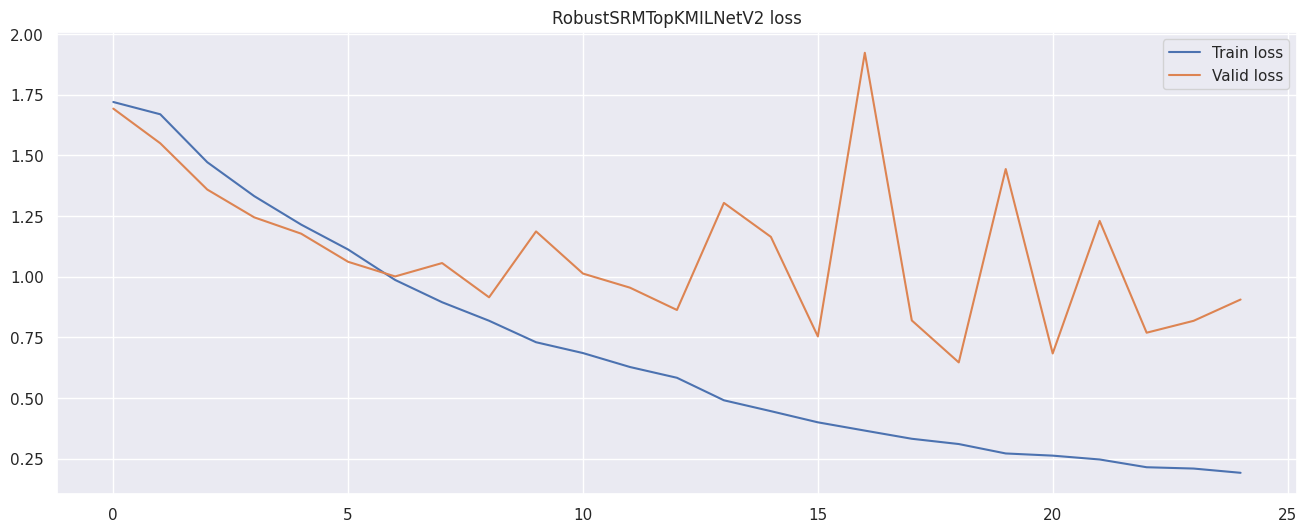

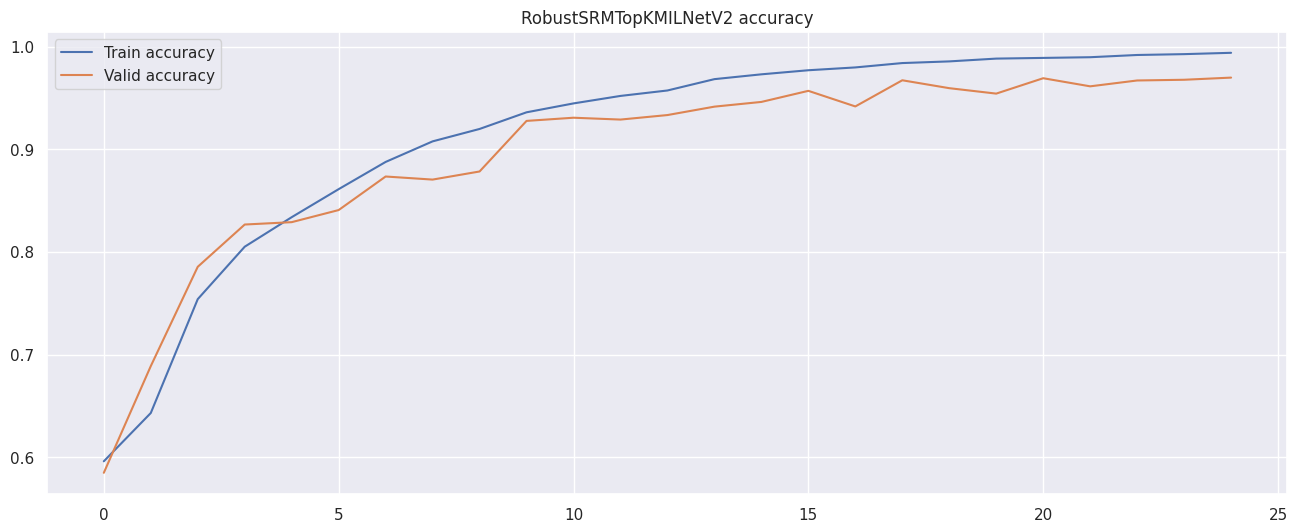

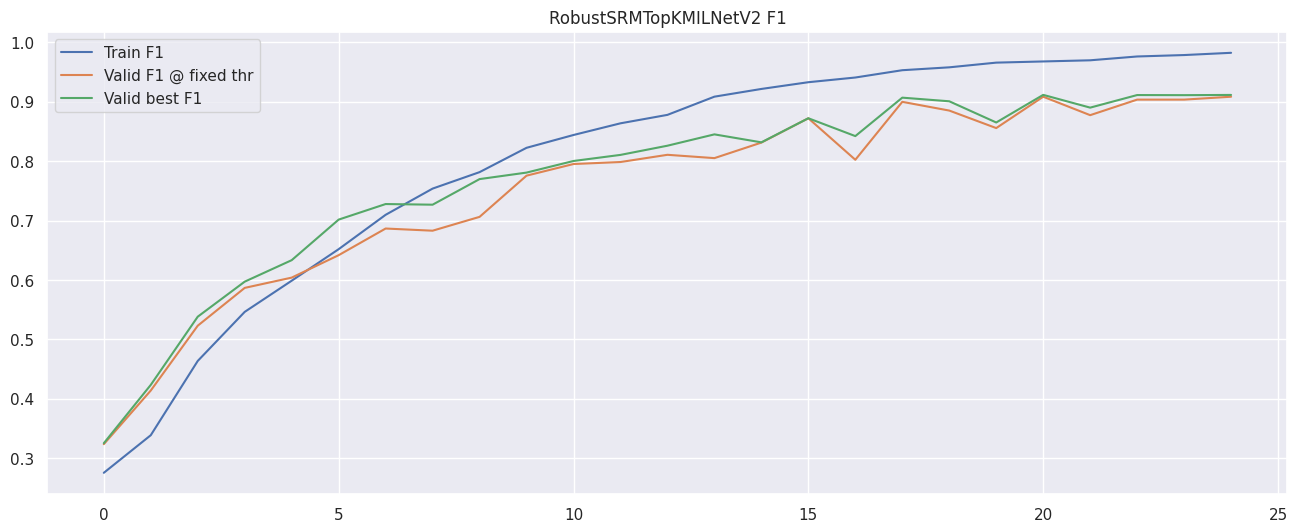

Epoch 25/60
Train loss: 0.1922 (final=0.0652, global=0.1043, local=0.4037)
Val loss:   0.9062 (final=0.5716, global=0.8861, local=0.4521)
Train acc:  0.9941 | Val acc @ fixed thr: 0.9699
Train F1:   0.9825
Val F1 @ fixed thr=0.50: 0.9086
Val BEST F1: 0.9116 at thr=0.300
Best Val F1 so far: 0.9117 (epoch 21)
Best checkpoint: /content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_BEST.pth


  0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
history = fit_v2(
    model=model,
    train_loader=train_loader,
    valid_loader=val_loader,
    optimizer=optimizer,
    loss_fn=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=60,
    title="RobustSRMTopKMILNetV2",
    fixed_threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    save_dir="/content/drive/MyDrive/YAN",
    use_amp=True,
    threshold_grid=np.arange(0.05, 0.96, 0.01),
)

/content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_epoch21_bestF1_0.9117_thr_0.640.pth

# Доработки

In [ ]:
loss_final_weight = 1.0
loss_global_weight = 0.10
loss_local_weight = 0.25
ema_decay = 0.999

In [ ]:
loss_global_weight=0.00
loss_local_weight=0.25

In [ ]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.auto import tqdm
from IPython.display import clear_output


# EMA

class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}

        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.detach().clone()

    @torch.no_grad()
    def update(self, model: nn.Module):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            assert name in self.shadow
            new_average = self.decay * self.shadow[name] + (1.0 - self.decay) * param.detach()
            self.shadow[name] = new_average.clone()

    def apply_shadow(self, model: nn.Module):
        self.backup = {}
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            assert name in self.shadow
            self.backup[name] = param.detach().clone()
            param.data.copy_(self.shadow[name].data)

    def restore(self, model: nn.Module):
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            assert name in self.backup
            param.data.copy_(self.backup[name].data)
        self.backup = {}


def clone_state_dict_to_cpu(model: nn.Module):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def unpack_batch(batch):
    if len(batch) == 2:
        x, y = batch
        batch_ids = None
    elif len(batch) == 3:
        batch_ids, x, y = batch
    else:
        raise ValueError(f"Unexpected batch format with len={len(batch)}")
    return batch_ids, x, y


def find_best_threshold_f1(y_true, probs, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.01)

    best_f1 = -1.0
    best_thr = 0.5

    for thr in threshold_grid:
        preds = (probs >= thr).astype(np.int32)
        f1 = f1_score(y_true, preds, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return float(best_f1), float(best_thr)


def compute_v2_loss(
    out_dict,
    y,
    criterion,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
):
    loss_final = criterion(out_dict["final_logit"], y)
    loss_global = criterion(out_dict["global_logit"], y)
    loss_local = criterion(out_dict["local_logit"], y)

    total_loss = (
        loss_final_weight * loss_final
        + loss_global_weight * loss_global
        + loss_local_weight * loss_local
    )

    return total_loss, loss_final.detach(), loss_global.detach(), loss_local.detach()



def plot_stats_v2_ema(
    train_loss,
    valid_loss,
    train_accuracy,
    valid_accuracy,
    train_f1,
    valid_f1_fixed,
    valid_f1_best,
    title,
):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(16, 6))
    plt.title(title + " loss")
    plt.plot(train_loss, label="Train loss")
    plt.plot(valid_loss, label="Valid loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " accuracy")
    plt.plot(train_accuracy, label="Train accuracy")
    plt.plot(valid_accuracy, label="Valid accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " F1")
    plt.plot(train_f1, label="Train F1")
    plt.plot(valid_f1_fixed, label="Valid F1 @ fixed thr")
    plt.plot(valid_f1_best, label="Valid best F1")
    plt.legend()
    plt.show()



def train_one_epoch_v2_ema(
    model: nn.Module,
    data_loader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    threshold=0.5,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
    use_amp=True,
    scaler=None,
    ema: ModelEMA = None,
):
    model.train()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_preds = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        _, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                loss_final_weight=loss_final_weight,
                loss_global_weight=loss_global_weight,
                loss_local_weight=loss_local_weight,
            )

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if ema is not None:
            ema.update(model)

        if scheduler is not None:
            scheduler.step()

        probs = torch.sigmoid(out_dict["final_logit"])
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_true, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="binary", zero_division=0)

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
    }



@torch.inference_mode()
def evaluate_v2_ema(
    model: nn.Module,
    data_loader,
    loss_fn,
    device,
    fixed_threshold=0.5,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
    use_amp=True,
    threshold_grid=None,
):
    model.eval()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_ids = []
    all_probs = []
    all_preds_fixed = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        batch_ids, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                loss_final_weight=loss_final_weight,
                loss_global_weight=loss_global_weight,
                loss_local_weight=loss_local_weight,
            )

        probs = torch.sigmoid(out_dict["final_logit"])
        preds_fixed = (probs >= fixed_threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_probs.extend(probs.cpu().numpy())
        all_preds_fixed.extend(preds_fixed.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

        if batch_ids is not None:
            if torch.is_tensor(batch_ids):
                all_ids.extend(batch_ids.cpu().numpy().tolist())
            else:
                all_ids.extend(batch_ids)

    all_probs = np.array(all_probs, dtype=np.float64)
    all_true = np.array(all_true, dtype=np.int32)
    all_preds_fixed = np.array(all_preds_fixed, dtype=np.int32)

    acc_fixed = accuracy_score(all_true, all_preds_fixed)
    prec_fixed = precision_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    rec_fixed = recall_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    f1_fixed = f1_score(all_true, all_preds_fixed, average="binary", zero_division=0)

    best_f1, best_thr = find_best_threshold_f1(
        y_true=all_true,
        probs=all_probs,
        threshold_grid=threshold_grid,
    )

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc_fixed": acc_fixed,
        "prec_fixed": prec_fixed,
        "rec_fixed": rec_fixed,
        "f1_fixed": f1_fixed,
        "best_f1": best_f1,
        "best_thr": best_thr,
        "probs": all_probs,
        "true": all_true,
        "ids": all_ids,
    }



def fit_v2_with_ema(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    num_epochs=10,
    title="RobustSRMTopKMILNetV2_EMA",
    fixed_threshold=0.5,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
    save_dir="/content/drive/MyDrive/YAN",
    use_amp=True,
    threshold_grid=None,
    use_ema=True,
    ema_decay=0.999,
):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history = []
    valid_f1_fixed_history = []
    valid_f1_best_history = []
    valid_best_thr_history = []

    best_valid_f1 = float("-inf")
    best_epoch = -1
    best_path = None

    os.makedirs(save_dir, exist_ok=True)

    amp_enabled = use_amp and (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    ema = ModelEMA(model, decay=ema_decay) if use_ema else None

    for epoch in range(num_epochs):
        train_stats = train_one_epoch_v2_ema(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            scheduler=scheduler,
            threshold=fixed_threshold,
            loss_final_weight=loss_final_weight,
            loss_global_weight=loss_global_weight,
            loss_local_weight=loss_local_weight,
            use_amp=use_amp,
            scaler=scaler,
            ema=ema,
        )

        if ema is not None:
            ema.apply_shadow(model)

        valid_stats = evaluate_v2_ema(
            model=model,
            data_loader=valid_loader,
            loss_fn=loss_fn,
            device=device,
            fixed_threshold=fixed_threshold,
            loss_final_weight=loss_final_weight,
            loss_global_weight=loss_global_weight,
            loss_local_weight=loss_local_weight,
            use_amp=use_amp,
            threshold_grid=threshold_grid,
        )

        if ema is not None:
            ema.restore(model)

        train_loss_history.append(train_stats["loss"])
        valid_loss_history.append(valid_stats["loss"])

        train_accuracy_history.append(train_stats["acc"])
        valid_accuracy_history.append(valid_stats["acc_fixed"])

        train_f1_history.append(train_stats["f1"])
        valid_f1_fixed_history.append(valid_stats["f1_fixed"])
        valid_f1_best_history.append(valid_stats["best_f1"])
        valid_best_thr_history.append(valid_stats["best_thr"])

        epoch_ckpt = {
            "sd": clone_state_dict_to_cpu(model),
            "epoch": epoch + 1,
            "cfg": vars(model.cfg) if hasattr(model, "cfg") else None,
            "val_best_f1": valid_stats["best_f1"],
            "val_best_thr": valid_stats["best_thr"],
            "fixed_threshold": fixed_threshold,
            "loss_final_weight": loss_final_weight,
            "loss_global_weight": loss_global_weight,
            "loss_local_weight": loss_local_weight,
            "use_ema": use_ema,
            "ema_decay": ema_decay,
        }

        if ema is not None:
            ema.apply_shadow(model)
            epoch_ckpt["ema_sd"] = clone_state_dict_to_cpu(model)
            ema.restore(model)

        epoch_path = os.path.join(
            save_dir,
            f"{title}_epoch{epoch+1}_bestF1_{valid_stats['best_f1']:.4f}_thr_{valid_stats['best_thr']:.3f}.pth"
        )
        torch.save(epoch_ckpt, epoch_path)

        if valid_stats["best_f1"] > best_valid_f1:
            best_valid_f1 = valid_stats["best_f1"]
            best_epoch = epoch + 1
            best_path = os.path.join(save_dir, f"{title}_BEST.pth")
            torch.save(epoch_ckpt, best_path)

        clear_output(wait=True)
        plot_stats_v2_ema(
            train_loss=train_loss_history,
            valid_loss=valid_loss_history,
            train_accuracy=train_accuracy_history,
            valid_accuracy=valid_accuracy_history,
            train_f1=train_f1_history,
            valid_f1_fixed=valid_f1_fixed_history,
            valid_f1_best=valid_f1_best_history,
            title=title,
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(
            f"Train loss: {train_stats['loss']:.4f} "
            f"(final={train_stats['loss_final']:.4f}, global={train_stats['loss_global']:.4f}, local={train_stats['loss_local']:.4f})"
        )
        print(
            f"Val loss:   {valid_stats['loss']:.4f} "
            f"(final={valid_stats['loss_final']:.4f}, global={valid_stats['loss_global']:.4f}, local={valid_stats['loss_local']:.4f})"
        )
        print(f"Train acc:  {train_stats['acc']:.4f} | Val acc @ fixed thr: {valid_stats['acc_fixed']:.4f}")
        print(f"Train F1:   {train_stats['f1']:.4f}")
        print(f"Val F1 @ fixed thr={fixed_threshold:.2f}: {valid_stats['f1_fixed']:.4f}")
        print(f"Val BEST F1: {valid_stats['best_f1']:.4f} at thr={valid_stats['best_thr']:.3f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f} (epoch {best_epoch})")
        print(f"Best checkpoint: {best_path}")
        if use_ema:
            print(f"EMA enabled: decay={ema_decay}")

    history = {
        "train_loss": train_loss_history,
        "valid_loss": valid_loss_history,
        "train_accuracy": train_accuracy_history,
        "valid_accuracy": valid_accuracy_history,
        "train_f1": train_f1_history,
        "valid_f1_fixed": valid_f1_fixed_history,
        "valid_f1_best": valid_f1_best_history,
        "valid_best_thr": valid_best_thr_history,
        "best_valid_f1": best_valid_f1,
        "best_epoch": best_epoch,
        "best_path": best_path,
    }

    return history

In [ ]:
ckpt_path = "/content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_epoch21_bestF1_0.9117_thr_0.640.pth"

ckpt = torch.load(ckpt_path, map_location=device)

cfg = RobustSRMTopKMILConfig(**ckpt["cfg"])

model_RobustSRMTopKMILNetV2 = RobustSRMTopKMILNetV2(cfg)

model_RobustSRMTopKMILNetV2.load_state_dict(ckpt["sd"])

model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2.to(device)
best_thr = ckpt.get("val_best_thr", 0.5)

print("Epoch:", ckpt.get("epoch"))
print("Best val F1:", ckpt.get("val_best_f1"))
print("Best threshold:", best_thr)

Epoch: 21
Best val F1: 0.9117203977101537
Best threshold: 0.6400000000000001


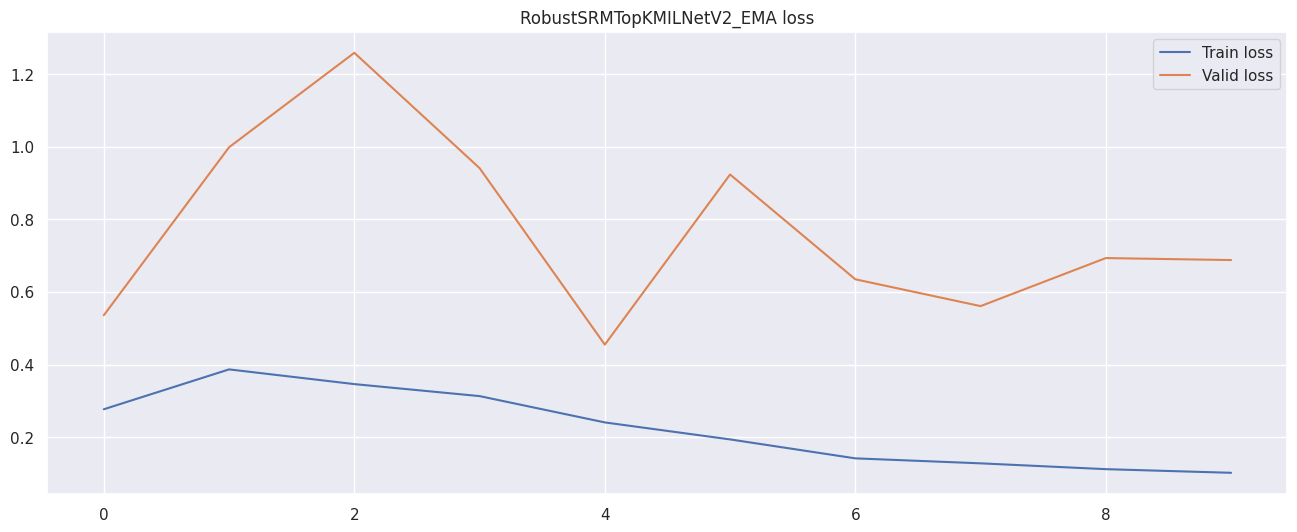

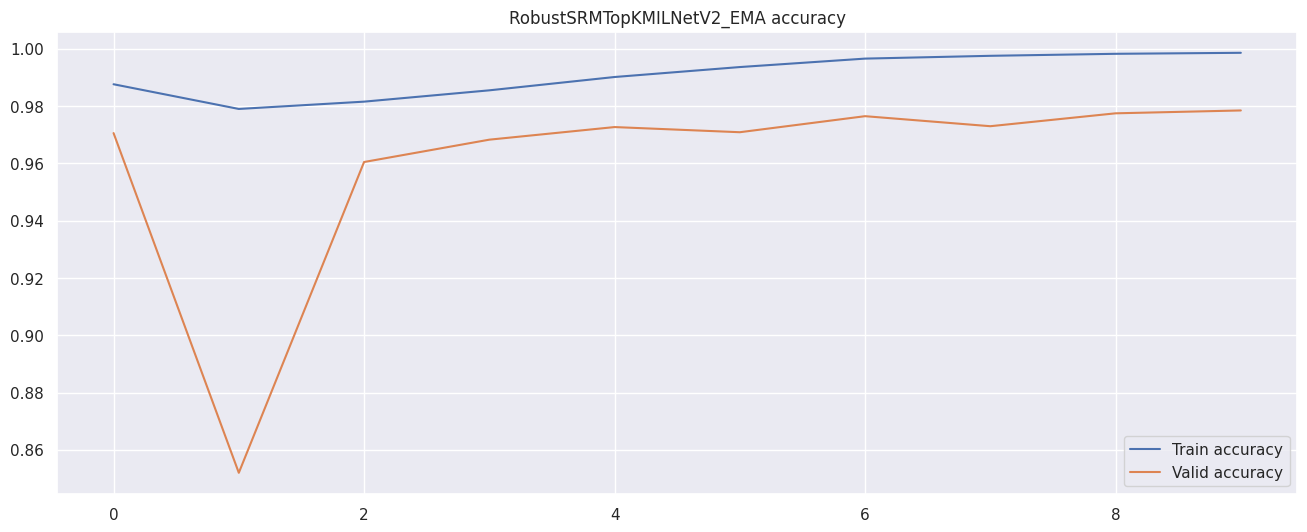

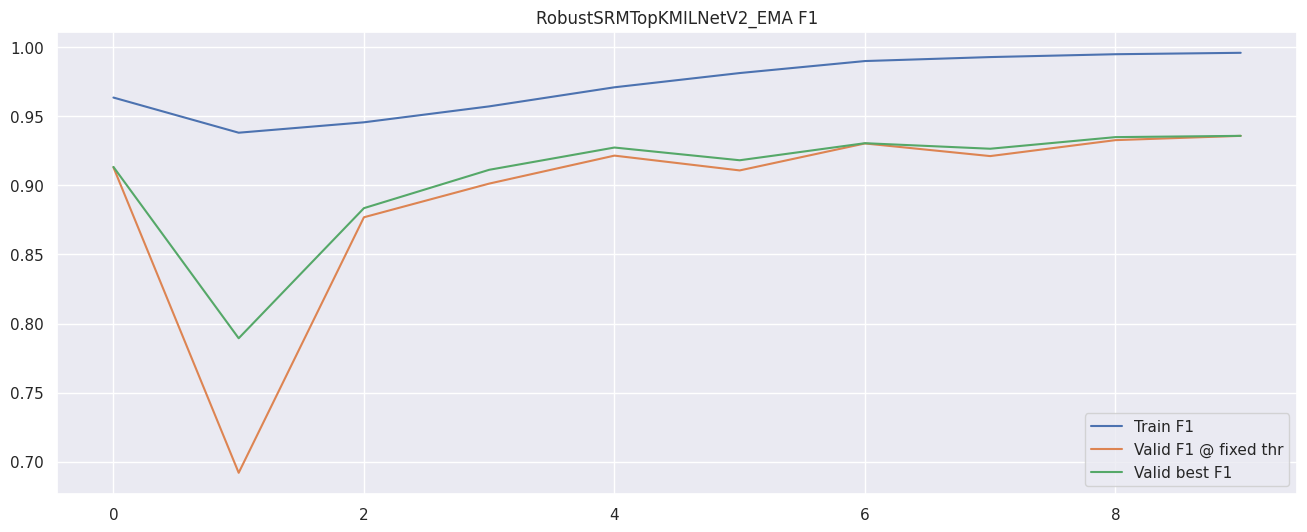

Epoch 10/10
Train loss: 0.1015 (final=0.0142, global=0.0276, local=0.3381)
Val loss:   0.6879 (final=0.5098, global=0.7558, local=0.4102)
Train acc:  0.9986 | Val acc @ fixed thr: 0.9785
Train F1:   0.9960
Val F1 @ fixed thr=0.50: 0.9358
Val BEST F1: 0.9358 at thr=0.480
Best Val F1 so far: 0.9358 (epoch 10)
Best checkpoint: /content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_EMA_BEST.pth
EMA enabled: decay=0.999


In [ ]:
criterion = build_weighted_bce_from_df(train_df, device)

optimizer = torch.optim.AdamW(
    model_RobustSRMTopKMILNetV2.parameters(),
    lr=3e-4,
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=10,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy="cos"
)

history = fit_v2_with_ema(
    model=model_RobustSRMTopKMILNetV2,
    train_loader=train_loader,
    valid_loader=val_loader,
    optimizer=optimizer,
    loss_fn=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=10,
    title="RobustSRMTopKMILNetV2_EMA",
    fixed_threshold=0.5,
    loss_final_weight=1.0,
    loss_global_weight=0.10,
    loss_local_weight=0.25,
    save_dir="/content/drive/MyDrive/YAN",
    use_amp=True,
    threshold_grid=np.arange(0.05, 0.96, 0.01),
    use_ema=True,
    ema_decay=0.999,
)